In [1]:
from neuromaps import NeuroMapOriginal, NeuroMapFixed

model_original = NeuroMapOriginal.load("checkpoints/original/model_final.ckpt")
fixed_model = NeuroMapFixed.load("checkpoints/fixed/model_final.ckpt")

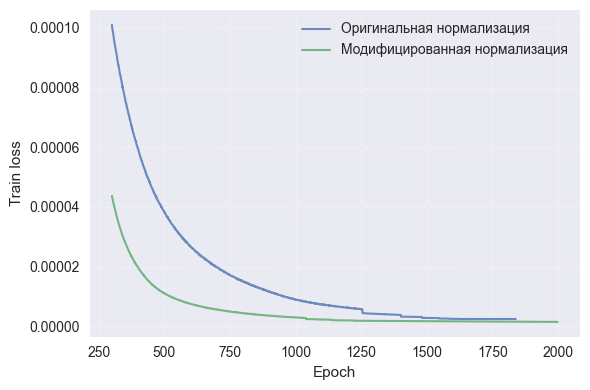

In [8]:
import matplotlib.pyplot as plt
import numpy as np

pass_first = 300
hist_o = model_original.training_history["train_loss"][pass_first:]
hist_f = fixed_model.training_history["train_loss"][pass_first:]

plt.style.use("seaborn-v0_8")
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

epochs_o = np.arange(pass_first, pass_first + len(hist_o))
epochs_f = np.arange(pass_first, pass_first + len(hist_f))

ax.plot(epochs_o, hist_o,
        label="Оригинальная нормализация", lw=1.5, alpha=.8)
ax.plot(epochs_f, hist_f,
        label="Модифицированная нормализация", lw=1.5, alpha=.8)

ax.set_xlabel("Epoch")
ax.set_ylabel("Train loss")
ax.legend()
ax.grid(True, ls="--", alpha=.3)
plt.tight_layout()
plt.show()

Симуляция: 100%|██████████████████████████████████████████| 20000/20000 [00:00<00:00, 37530.29шаг/s]


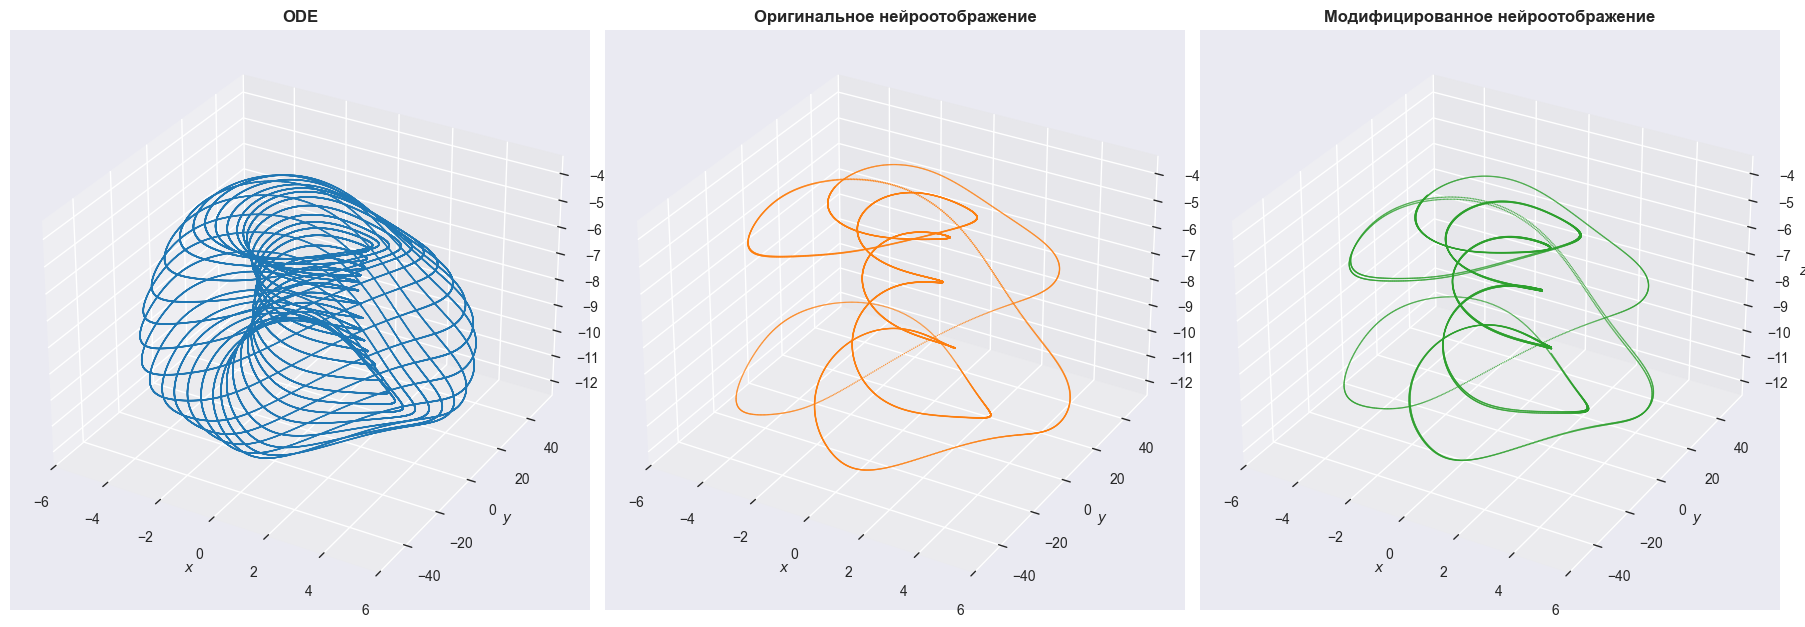

In [9]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import generator_3d_rk4, generator_3d_right_part

u0 = [-10, -100, -20]
p = [6, 1/23, 8, 0.02]

nm_orig_traj = model_original.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)
nm_modf_traj = fixed_model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)
ode_traj = get_attractor_trajectory(generator_3d_rk4, generator_3d_right_part, u0, p, 0.001, 300, 200,
                                    lambda x, y: x[1], lambda x, y: [0, 1, 0], divergence_threshold=1e3)

if nm_orig_traj is not None:
    nm_orig_traj = nm_orig_traj[10000:]
if nm_modf_traj is not None:
    nm_modf_traj = nm_modf_traj[10000:]

plot_compare_trajectories(ode_traj, nm_orig_traj, nm_modf_traj, labels=['ODE', 'Оригинальное нейроотображение', 'Модифицированное нейроотображение'],
layout='sidebyside')